# Site climate timeseries

P+I and reference ET for one site, at hourly (native), daily-mean, monthly-mean, and annual-mean
resolution. Writes one zarr store per case to
`.../postprocessed/met_forcing_rxn/clim_dat_<site>_<case>.zarr`.

In [74]:
import s3fs
import numpy as np
import pandas as pd
import xarray as xr

from byte_util import all_sites

SITE = "Pullman"       # any of `all_sites`
START_YEAR = 2001           # first year of climate data to save (inclusive)
END_YEAR = 2010             # last year of climate data to save (inclusive)
WRITE = True
OVERWRITE = True

CLIM_DIR = "carbonplan-carbon-removal/ew-workflows-data/min3p/input-data/processed-data/climate"
OUT_ROOT = ("s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations"
            "/postprocessed/met_forcing_rxn")

assert SITE in all_sites
fs = s3fs.S3FileSystem(anon=False)

In [75]:
# P + I (mm/hr) and reference ET (mm/hr), both indexed on the same hourly UTC `valid_time`
with fs.open(f"{CLIM_DIR}/HourlySurfaceWaterBalance.parquet") as f:
    wb = pd.read_parquet(f, columns=[f"{SITE}_precip_mm.hr", f"{SITE}_irrig_mm.hr"])
p_plus_i = wb.sum(axis=1).rename("p_plus_i")

with fs.open(f"{CLIM_DIR}/ref_et.csv") as f:
    ref_et = pd.read_csv(f, usecols=["valid_time", SITE], index_col="valid_time",
                          parse_dates=True)[SITE].rename("ref_et")

hourly = pd.concat([p_plus_i, ref_et], axis=1).dropna()
hourly.index.name = "time"
hourly = hourly.loc[f"{START_YEAR}":f"{END_YEAR}"]

In [ ]:
# One dataset per aggregation case. Coarser cases are the mean of the hourly rate (not a sum),
# so units stay mm/hr at every case. 
# "longterm" repeats the single mean over the full period once per year, on the same annual
# time coordinate as the "annual" case, so it plots as a flat reference line alongside it.
CASES = {"hourly": None, "daily": "D", "monthly": "ME", "annual": "YE"}

datasets = {}
for case, freq in CASES.items():
    df = hourly if freq is None else hourly.resample(freq).mean()
    ds = xr.Dataset(
        {"p_plus_i": ("time", df["p_plus_i"].to_numpy(np.float32)),
         "ref_et": ("time", df["ref_et"].to_numpy(np.float32))},
        coords={"time": df.index.to_numpy()},
        attrs={"site": SITE, "case": case},
    )
    ds["p_plus_i"].attrs = {"units": "mm/hr", "long_name": "precipitation + irrigation"}
    ds["ref_et"].attrs = {"units": "mm/hr", "long_name": "reference evapotranspiration"}
    datasets[case] = ds

longterm_mean = hourly.mean()
annual_time = datasets["annual"]["time"].to_numpy()
ds = xr.Dataset(
    {"p_plus_i": ("time", np.full(annual_time.shape, longterm_mean["p_plus_i"], dtype=np.float32)),
     "ref_et": ("time", np.full(annual_time.shape, longterm_mean["ref_et"], dtype=np.float32))},
    coords={"time": annual_time},
    attrs={"site": SITE, "case": "longterm"},
)
ds["p_plus_i"].attrs = {"units": "mm/hr", "long_name": "precipitation + irrigation"}
ds["ref_et"].attrs = {"units": "mm/hr", "long_name": "reference evapotranspiration"}
datasets["longterm"] = ds

In [77]:
datasets['longterm']

<xarray.Dataset> Size: 160B
Dimensions:   (time: 10)
Coordinates:
  * time      (time) datetime64[us] 80B 2001-12-31 2002-12-31 ... 2010-12-31
Data variables:
    p_plus_i  (time) float32 40B 0.1477 0.1477 0.1477 ... 0.1477 0.1477 0.1477
    ref_et    (time) float32 40B 0.1813 0.1813 0.1813 ... 0.1813 0.1813 0.1813
Attributes:
    site:     Pullman
    case:     longterm

In [78]:
for case, ds in datasets.items():
    url = f"{OUT_ROOT}/clim_dat_{SITE}_{case}.zarr"
    if WRITE:
        if not OVERWRITE and fs.exists(url.replace("s3://", "")):
            raise FileExistsError(f"{url} exists and OVERWRITE is False")
        ds.chunk({"time": ds.sizes["time"]}).to_zarr(url, mode="w", zarr_format=2, consolidated=True)
    print(case, dict(ds.sizes), url)

hourly {'time': 87648} s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations/postprocessed/met_forcing_rxn/clim_dat_Pullman_hourly.zarr
daily {'time': 3652} s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations/postprocessed/met_forcing_rxn/clim_dat_Pullman_daily.zarr
monthly {'time': 120} s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations/postprocessed/met_forcing_rxn/clim_dat_Pullman_monthly.zarr
annual {'time': 10} s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations/postprocessed/met_forcing_rxn/clim_dat_Pullman_annual.zarr
longterm {'time': 10} s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations/postprocessed/met_forcing_rxn/clim_dat_Pullman_longterm.zarr


Text(0.5, 0.98, 'Pullman')

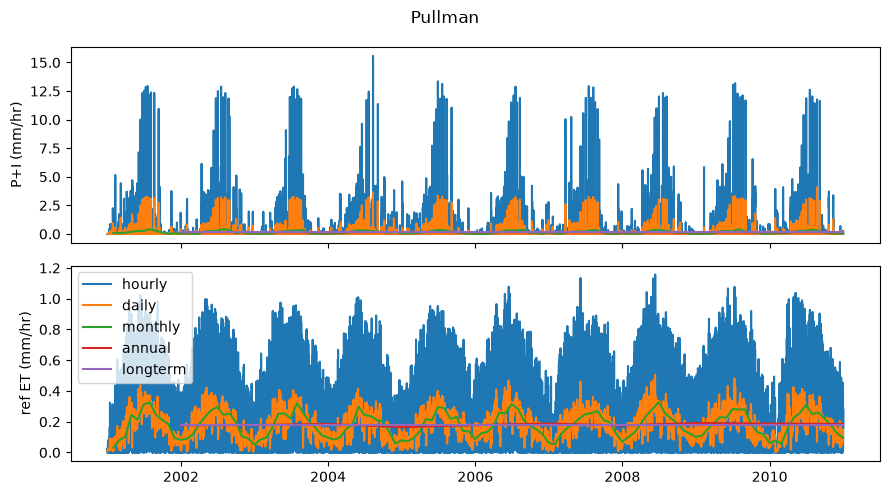

In [79]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, tight_layout=True)
for case, ds in datasets.items():
    axes[0].plot(ds["time"], ds["p_plus_i"], label=case)
    axes[1].plot(ds["time"], ds["ref_et"], label=case)
axes[0].set_ylabel("P+I (mm/hr)")
axes[1].set_ylabel("ref ET (mm/hr)")
axes[1].legend()
fig.suptitle(SITE)

In [49]:
# ---